In [1]:
from pathlib import Path

import holidays
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error

In [3]:
DATA_PATH = Path("../data/processed/sardinia_hourly.parquet")
df = pd.read_parquet(DATA_PATH)
df = df.rename(columns={"Total Load [MW]": "load"})
df = df.rename(columns={"Forecast Total Load [MW]": "terna-forecast"})

display(df.head())

,load,terna-forecast
Date,,
2023-01-01 00:00:00+01:00,806.13675,833.01000
2023-01-01 01:00:00+01:00,783.55525,779.20525
2023-01-01 02:00:00+01:00,753.62675,749.15025
2023-01-01 03:00:00+01:00,736.34950,739.18250
2023-01-01 04:00:00+01:00,723.29950,749.01150


In [4]:
df["lag_24h"] = df["load"].shift(24)
df["lag_48h"] = df["load"].shift(48)
df["lag_168h"] = df["load"].shift(168)

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h"]
    ].head(170)
)

,load,lag_24h,lag_48h,lag_168h
Date,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN
...,...,...,...,...
2023-01-07 21:00:00+01:00,1009.19525,1012.38225,1034.62100,NaN
2023-01-07 22:00:00+01:00,938.51400,943.02550,977.22425,NaN
2023-01-07 23:00:00+01:00,865.93575,863.03125,890.10025,NaN


In [5]:
italian_holidays = holidays.Italy(
    years=range(df.index.year.min(), df.index.year.max() + 1)
)

local_dates = df.index.tz_convert("Europe/Rome").date

In [6]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df.index.dayofweek >= 5).astype(int)
df["is_holiday"] = [
    int(date in italian_holidays)
    for date in local_dates
]

display(
    df[
        ["load", "lag_24h", "lag_48h", "lag_168h",
         "hour", "day_of_week", "month", "is_weekend", "is_holiday"]
    ].head()
)

,load,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_weekend,is_holiday
Date,,,,,,,,,
2023-01-01 00:00:00+01:00,806.13675,NaN,NaN,NaN,0,6,1,1,1
2023-01-01 01:00:00+01:00,783.55525,NaN,NaN,NaN,1,6,1,1,1
2023-01-01 02:00:00+01:00,753.62675,NaN,NaN,NaN,2,6,1,1,1
2023-01-01 03:00:00+01:00,736.34950,NaN,NaN,NaN,3,6,1,1,1
2023-01-01 04:00:00+01:00,723.29950,NaN,NaN,NaN,4,6,1,1,1


In [7]:
features = [
    "lag_24h",
    "lag_48h",
    "lag_168h",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "is_holiday"
]

model_df = df[["load"] + features].dropna()

X = model_df[features]
y = model_df["load"]

print(f"Usable rows: {len(model_df):,}")
display(X.head())
display(X.tail())

Usable rows: 32,663


,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_weekend,is_holiday
Date,,,,,,,,
2023-01-08 00:00:00+01:00,800.01925,804.50900,806.13675,0,6,1,1,0
2023-01-08 01:00:00+01:00,751.25225,747.51300,783.55525,1,6,1,1,0
2023-01-08 02:00:00+01:00,721.83825,718.40800,753.62675,2,6,1,1,0
2023-01-08 03:00:00+01:00,712.11975,707.29675,736.34950,3,6,1,1,0
2023-01-08 04:00:00+01:00,717.85975,708.24825,723.29950,4,6,1,1,0


,lag_24h,lag_48h,lag_168h,hour,day_of_week,month,is_weekend,is_holiday
Date,,,,,,,,
2026-10-05 19:00:00+02:00,950.88050,961.34675,1035.88400,19,0,10,0,0
2026-10-05 20:00:00+02:00,955.09125,944.11200,1028.13000,20,0,10,0,0
2026-10-05 21:00:00+02:00,899.96900,866.38775,950.25450,21,0,10,0,0
2026-10-05 22:00:00+02:00,825.99125,805.69525,876.46550,22,0,10,0,0
2026-10-05 23:00:00+02:00,766.50825,756.42250,810.22375,23,0,10,0,0


In [8]:
X_train = X.loc[:"2025-12-31 23:59:59"]
y_train = y.loc[X_train.index]

X_test = X.loc["2026-01-01":]
y_test = y.loc[X_test.index]

print(f"Train: {X_train.index.min()} -> {X_train.index.max()} ({len(X_train):,} rows)")
print(f"Test:  {X_test.index.min()} -> {X_test.index.max()} ({len(X_test):,} rows)")

Train: 2023-01-08 00:00:00+01:00 -> 2025-12-31 23:00:00+01:00 (26,136 rows)
Test:  2026-01-01 00:00:00+01:00 -> 2026-10-05 23:00:00+02:00 (6,527 rows)


In [9]:
model = HistGradientBoostingRegressor(
    random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

print(f"Predictions: {len(pred):,}")

Predictions: 6,527


In [10]:
rmse_model = root_mean_squared_error(y_test, pred)
mae_model = mean_absolute_error(y_test, pred)
mape_model = mean_absolute_percentage_error(
    y_test,
    pred
) * 100

print(f"MAE model: {mae_model:.2f} MW")
print(f"RMSE model: {rmse_model:.2f} MW")
print(f"MAPE model: {mape_model:.2f}%")

MAE model: 35.46 MW
RMSE model: 51.88 MW
MAPE model: 3.26%


In [11]:
results = pd.DataFrame(
    {
        "actual": y_test,
        "prediction": pred
    },
    index=y_test.index
)

results["error"] = results["actual"] - results["prediction"]
results["absolute_error"] = results["error"].abs()

display(results.head())

,actual,prediction,error,absolute_error
Date,,,,
2026-01-01 00:00:00+01:00,809.42325,777.551171,31.872079,31.872079
2026-01-01 01:00:00+01:00,774.35375,745.888547,28.465203,28.465203
2026-01-01 02:00:00+01:00,740.69925,720.600809,20.098441,20.098441
2026-01-01 03:00:00+01:00,716.15600,699.338310,16.817690,16.817690
2026-01-01 04:00:00+01:00,706.16175,703.633672,2.528078,2.528078


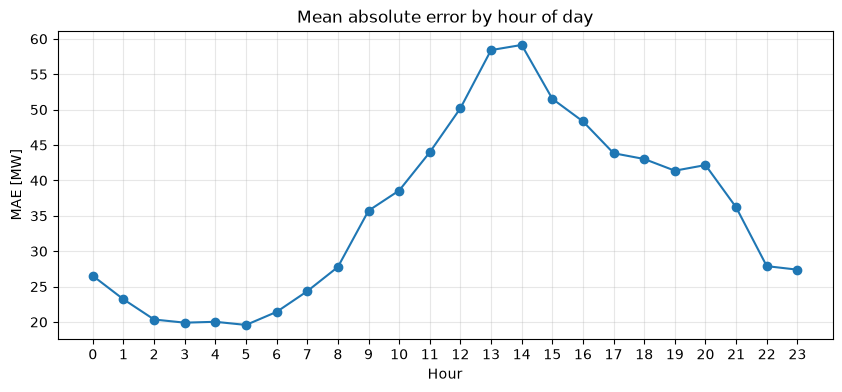

In [12]:
error_by_hour = (
    results.groupby(results.index.hour)["absolute_error"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))

error_by_hour.plot(ax=ax, marker="o")

ax.set_title("Mean absolute error by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAE [MW]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

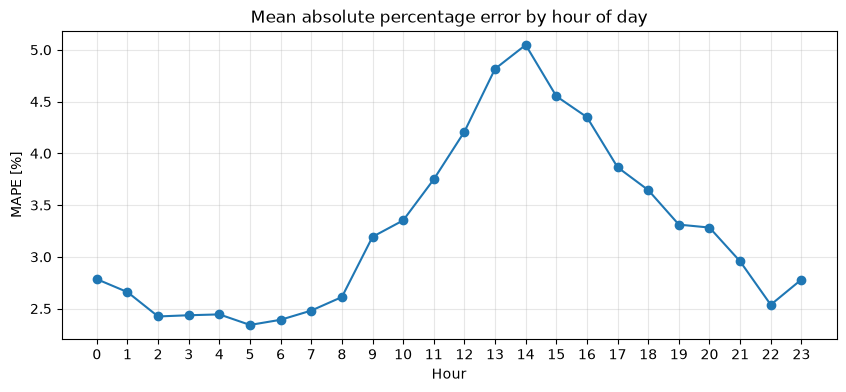

In [13]:
results["absolute_percentage_error"] = (
    results["absolute_error"] / results["actual"] * 100
)

mape_by_hour = (
    results.groupby(results.index.hour)["absolute_percentage_error"]
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 4))

mape_by_hour.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by hour of day")
ax.set_xlabel("Hour")
ax.set_ylabel("MAPE [%]")
ax.set_xticks(range(24))
ax.grid(alpha=0.3)

plt.show()

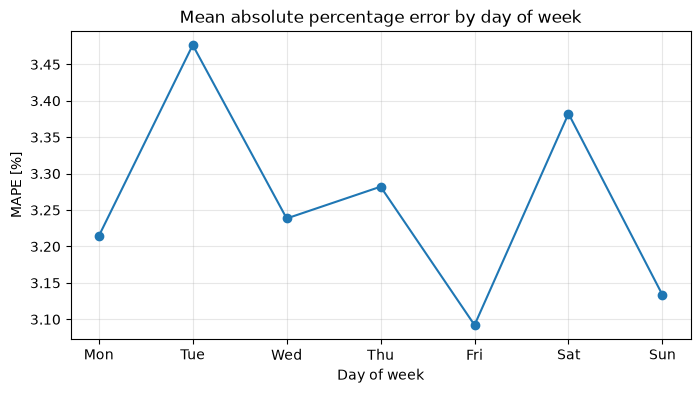

In [14]:
mape_by_weekday = (
    results.groupby(results.index.dayofweek)["absolute_percentage_error"]
    .mean()
)

mape_by_weekday.index = [
    "Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"
]

fig, ax = plt.subplots(figsize=(8, 4))

mape_by_weekday.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by day of week")
ax.set_xlabel("Day of week")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()

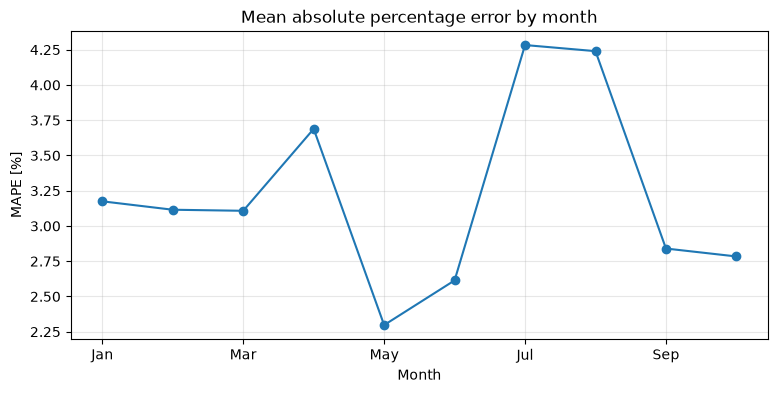

In [15]:
mape_by_month = (
    results.groupby(results.index.month)["absolute_percentage_error"]
    .mean()
)

mape_by_month.index = [
    "Jan", "Feb", "Mar", "Apr", "May",
    "Jun", "Jul", "Aug", "Sep", "Oct"
]

fig, ax = plt.subplots(figsize=(9, 4))

mape_by_month.plot(ax=ax, marker="o")

ax.set_title("Mean absolute percentage error by month")
ax.set_xlabel("Month")
ax.set_ylabel("MAPE [%]")
ax.grid(alpha=0.3)

plt.show()